In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from numba import njit

@njit
def rbf_gaussian(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = np.exp(-b**2 * r**2)
    return out

@njit
def d2rbf_gaussian(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = (4 * b**4 * r**2 - 2 * b**2) * np.exp(-b**2 * r**2)
    return out

@njit
def rbf_mq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = np.sqrt(1 + (b * r)**2)
    return out

@njit
def d2rbf_mq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            denom = (1 + (b * r)**2)**(3/2)
            out[i, j] = b**2 / denom
    return out

@njit
def rbf_imq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = 1.0 / np.sqrt(1 + (b * r)**2)
    return out

@njit
def d2rbf_imq(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            denom = (1 + (b * r)**2)**(5/2)
            out[i, j] = b**2 * (3 * (b * r)**2 - 1) / denom
    return out

@njit
def rbf_invquad(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = 1.0 / (1 + (b * r)**2)
    return out

@njit
def d2rbf_invquad(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            denom = (1 + (b * r)**2)**3
            out[i, j] = 2 * b**2 * (3 * (b * r)**2 - 1) / denom
    return out



# -------- Wendland C^2:  φ(s) = (1 - s)^4 (4s + 1),  s = b |x-c| ∈ [0,1] --------
@njit
def rbf_wendland_c2(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            s = b * abs(x[i] - c[j])
            if s < 1.0:
                t = 1.0 - s
                out[i, j] = (t**4) * (4.0*s + 1.0)
            else:
                out[i, j] = 0.0
    return out

@njit
def d2rbf_wendland_c2(x, c, b):

    out = np.zeros((x.size, c.size))
    b2 = b*b
    for i in range(x.size):
        for j in range(c.size):
            s = b * abs(x[i] - c[j])
            if s < 1.0:
                t = 1.0 - s
                out[i, j] = b2 * (-20.0) * (t**2) * (1.0 - 4.0*s)
            else:
                out[i, j] = 0.0
    return out

# -------- Wendland C^4:  phi(s) = (1 - s)^6 (35 s^2 + 18 s + 3), s = b |x-c| in [0,1] --------
@njit
def rbf_wendland_c4(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            s = b * abs(x[i] - c[j])
            if s < 1.0:
                t = 1.0 - s
                poly = 35.0*s*s + 18.0*s + 3.0
                out[i, j] = (t**6) * poly
            else:
                out[i, j] = 0.0
    return out

@njit
def d2rbf_wendland_c4(x, c, b):
    # phi''_C4(s) = 28 * (1 - s)^4 * (70 s^2 - 8 s - 2), for 0 <= s < 1; then multiply by b^2
    out = np.zeros((x.size, c.size))
    b2 = b*b
    for i in range(x.size):
        for j in range(c.size):
            s = b * abs(x[i] - c[j])
            if s < 1.0:
                t = 1.0 - s
                out[i, j] = b2 * 28.0 * (t**4) * (70.0*s*s - 8.0*s - 2.0)
            else:
                out[i, j] = 0.0
    return out



# Problem domain and parameters
L = 5.0
beta = 3e5

def u_exact_func(x):
    return np.sin(np.pi * x) / (np.pi**2 + 1)

#############################
# --- RBF solver ---
#############################

def run_rbf_solver(
    N,
    rbf_func,              # callable: rbf_func(x, c, b) -> (len(x)×len(c)) matrix
    d_rbf_func,            # callable: d_rbf_func(x, c, b) -> first-derivative matrix wrt x
    L=5.0,
    Amplitude=50.0,
    beta=3e5,
    tau=1e-15,
    c_shape=0.134,
    zeta=2,
    T_cent=1.0,
    use_trapezoid_weights=True,   # True: trapezoid; False: uniform dx
    penalty_prefactor=1.0,        # 1.0 (this script) or 2.0 (earlier variant)
    use_sqrtN_rep=True,           # u = (1/√N) Φ w if True
    jitter=False,
    jitter_scale=1e-6,
):
    """
    Variational RBF TSVD solver for -u'' + u = A sin(πx) on [0,L], u(0)=u(L)=0.
    Basis is supplied by rbf_func and its first derivative d_rbf_func.

    Returns: (relative_L2_error_squared, peak_mem_MB, runtime_s)
    """
    import numpy as np
    import time, tracemalloc
    from numpy.linalg import svd

    # --- centers & grids ---
    a, b = 0.0, float(L)
    Lh = 0.5 * (b - a); q = 0.5 * (a + b)

    centers = np.linspace(q - T_cent * Lh, q + T_cent * Lh, N).astype(np.float64)
    if jitter:
        centers += np.random.normal(0.0, jitter_scale, size=N)
        centers = np.clip(centers, q - T_cent * Lh, q + T_cent * Lh)

    M = max(4, int(zeta * N))
    x_int = np.linspace(a, b, M).astype(np.float64)
    dx = (b - a) / (M - 1)

    # shape parameter
    eps = float(c_shape * N)

    # --- basis & derivative (use provided call signatures) ---
    # Each returns an (M × N) matrix
    Phi   = rbf_func(x_int, centers, eps).astype(np.float64)
    Phi_x = d_rbf_func(x_int, centers, eps).astype(np.float64)

    # --- weights & core matrices ---
    if use_trapezoid_weights:
        wts = np.ones(M, dtype=np.float64); wts[0] = wts[-1] = 0.5
        W = (wts * dx)[:, None]                         # (M × 1)
        A_core = Phi_x.T @ (W * Phi_x) + Phi.T @ (W * Phi)
        b_core = Phi.T @ ((wts * dx) * (Amplitude * np.sin(np.pi * x_int)))
    else:
        A_core = dx * (Phi_x.T @ Phi_x + Phi.T @ Phi)
        b_core = dx * (Phi.T @ (Amplitude * np.sin(np.pi * x_int)))

    # --- boundary penalty rows: evaluate basis at scalars a,b ---
    # rbf_func expects arrays, so feed 1-length arrays and take row 0
    P0 = rbf_func(np.array([a], dtype=np.float64), centers, eps)[0, :].astype(np.float64)
    PL = rbf_func(np.array([b], dtype=np.float64), centers, eps)[0, :].astype(np.float64)
    A_pen = penalty_prefactor * float(beta) * (np.outer(P0, P0) + np.outer(PL, PL))

    # System
    A = (A_core + A_pen).astype(np.float64)
    b_vec = b_core.astype(np.float64)

    # Optional 1/√N representation ⇒ multiply RHS by √N (see earlier derivation)
    rhs = (np.sqrt(N) * b_vec) if use_sqrtN_rep else b_vec

    # --- TSVD solve: threshold = tau * σ_max ---
    tracemalloc.start()
    t0 = time.perf_counter()

    U, s, Vt = svd(A, full_matrices=False)
    cutoff = float(tau) * s[0]
    keep = s > cutoff
    inv_s = np.zeros_like(s); inv_s[keep] = 1.0 / s[keep]
    w_tsvd = (Vt.T * inv_s) @ (U.T @ rhs)

    runtime = time.perf_counter() - t0
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # --- evaluate on x_int (reuse Phi) ---
    if use_sqrtN_rep:
        u_num = (1.0 / np.sqrt(N)) * (Phi @ w_tsvd)
    else:
        u_num = Phi @ w_tsvd

    u_ex = (Amplitude * np.sin(np.pi * x_int) / (1.0 + np.pi**2)).astype(np.float64)

    # Relative L2 (squared), consistent with assembly weighting
    if use_trapezoid_weights:
        err2 = np.sum((u_num - u_ex)**2 * (wts * dx))
        ref2 = np.sum(u_ex**2 * (wts * dx))
    else:
        err2 = dx * np.sum((u_num - u_ex)**2)
        ref2 = dx * np.sum(u_ex**2)

    rel_L2_sq = err2 / max(ref2, 1e-300)
    return rel_L2_sq, peak / (1024 * 1024), runtime


In [4]:
# ---------- RBF helpers: pick (phi, dphi/dx) by name or provide your own ----------

def _d_rbf_gaussian(x, c, b):
    # analytic d/dx of exp(-(b r)^2), r = x - c
    x = np.asarray(x, dtype=float); c = np.asarray(c, dtype=float)
    out = np.zeros((x.size, c.size), dtype=float)
    bb = b*b
    for i in range(x.size):
        xi = x[i]
        for j in range(c.size):
            r = xi - c[j]
            out[i, j] = -2.0 * bb * r * np.exp(-bb * r*r)
    return out

def _numeric_dphi(phi_func, h=1e-6):
    # central-difference wrapper to approximate d/dx phi(x,c,b)
    def dphi_dx(x, c, b):
        x = np.asarray(x, dtype=float)
        return (phi_func(x + h, c, b) - phi_func(x - h, c, b)) / (2.0*h)
    return dphi_dx

def get_rbf_pair(rbf_type: str, h=1e-6):
    """
    Return (phi, dphi_dx) by name, using analytic dphi_dx for Gaussian
    and numeric dphi_dx otherwise (since your code defines d2* but not d*).
    """
    name = rbf_type.strip().lower()
    if name in ["gaussian", "gauss"]:
        return rbf_gaussian, _d_rbf_gaussian
    elif name in ["mq", "multiquadric"]:
        return rbf_mq, _numeric_dphi(rbf_mq, h=h)
    elif name in ["imq", "inverse multiquadric", "inverse-mq"]:
        return rbf_imq, _numeric_dphi(rbf_imq, h=h)
    elif name in ["invquad", "inverse quadratic", "inverse-quad"]:
        return rbf_invquad, _numeric_dphi(rbf_invquad, h=h)
    elif name in ["wendland c2", "wendland_c2", "wendland-c2"]:
        return rbf_wendland_c2, _numeric_dphi(rbf_wendland_c2, h=h)
    elif name in ["wendland c4", "wendland_c4", "wendland-c4"]:
        return rbf_wendland_c4, _numeric_dphi(rbf_wendland_c4, h=h)
    else:
        raise ValueError(f"Unknown RBF type: {rbf_type}")

# -----------------------------
# Variational RBF TSVD solver
# -----------------------------
def run_rbf_solver(
    N,
    rbf_func=None,            # optional: callable phi(x,c,b) -> (M×N)
    d_rbf_func=None,          # optional: callable dphi/dx(x,c,b) -> (M×N)
    rbf_type="Gaussian",      # used if funcs are not provided
    L=5.0,
    Amplitude=50.0,
    beta=3e5,
    tau=1e-15,
    c_shape=0.134,
    zeta=2,
    T_cent=1.0,
    use_trapezoid_weights=True,   # True: trapezoid; False: uniform dx
    penalty_prefactor=1.0,        # 1.0 (this script) or 2.0 (earlier variant)
    use_sqrtN_rep=True,           # u = (1/√N) Φ w if True
    jitter=False,
    jitter_scale=1e-6,
):
    """
    Variational RBF TSVD solver for -u'' + u = A sin(πx) on [0,L], u(0)=u(L)=0.
    Accepts either explicit (rbf_func, d_rbf_func) or a kernel name via rbf_type.

    Returns: (relative_L2_error_squared, peak_mem_MB, runtime_s)
    """
    import time, tracemalloc
    from numpy.linalg import svd

    # pick kernel pair if not provided
    if (rbf_func is None) or (d_rbf_func is None):
        rbf_func, d_rbf_func = get_rbf_pair(rbf_type)

    # domain, centers, grid
    a, bnd = 0.0, float(L)
    Lh = 0.5*(bnd - a); q = 0.5*(a + bnd)
    centers = np.linspace(q - T_cent*Lh, q + T_cent*Lh, N).astype(float)
    if jitter:
        centers += np.random.normal(0.0, jitter_scale, size=N)
        centers = np.clip(centers, q - T_cent*Lh, q + T_cent*Lh)

    M = max(4, int(zeta*N))
    x_int = np.linspace(a, bnd, M).astype(float)
    dx = (bnd - a) / (M - 1)

    # shape parameter
    eps = float(c_shape * N)

    # basis & first derivative
    Phi   = rbf_func(x_int, centers, eps).astype(float)     # M×N
    Phi_x = d_rbf_func(x_int, centers, eps).astype(float)   # M×N

    # weights & core
    if use_trapezoid_weights:
        wts = np.ones(M, dtype=float); wts[0] = wts[-1] = 0.5
        W = (wts * dx)[:, None]
        A_core = Phi_x.T @ (W * Phi_x) + Phi.T @ (W * Phi)
        b_core = Phi.T @ ((wts * dx) * (Amplitude * np.sin(np.pi * x_int)))
    else:
        A_core = dx * (Phi_x.T @ Phi_x + Phi.T @ Phi)
        b_core = dx * (Phi.T @ (Amplitude * np.sin(np.pi * x_int)))

    # penalty (phi at endpoints)
    P0 = rbf_func(np.array([a], dtype=float), centers, eps)[0, :].astype(float)
    PL = rbf_func(np.array([bnd], dtype=float), centers, eps)[0, :].astype(float)
    A_pen = penalty_prefactor * float(beta) * (np.outer(P0, P0) + np.outer(PL, PL))

    A = (A_core + A_pen).astype(float)
    b_vec = b_core.astype(float)

    # 1/√N representation ⇒ RHS *= √N; evaluate with 1/√N later
    rhs = (np.sqrt(N) * b_vec) if use_sqrtN_rep else b_vec

    # TSVD solve with cutoff = tau * σ_max
    tracemalloc.start()
    t0 = time.perf_counter()
    U, s, Vt = svd(A, full_matrices=False)
    cutoff = float(tau) * s[0]
    keep = s > cutoff
    inv_s = np.zeros_like(s); inv_s[keep] = 1.0 / s[keep]
    w_tsvd = (Vt.T * inv_s) @ (U.T @ rhs)
    runtime = time.perf_counter() - t0
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # evaluate on x_int
    if use_sqrtN_rep:
        u_num = (1.0 / np.sqrt(N)) * (Phi @ w_tsvd)
    else:
        u_num = Phi @ w_tsvd
    u_ex = (Amplitude * np.sin(np.pi * x_int) / (1.0 + np.pi**2)).astype(float)

    # relative L2 (squared) with same weights as assembly
    if use_trapezoid_weights:
        err2 = np.sum((u_num - u_ex)**2 * (wts * dx))
        ref2 = np.sum(u_ex**2 * (wts * dx))
    else:
        err2 = dx * np.sum((u_num - u_ex)**2)
        ref2 = dx * np.sum(u_ex**2)

    rel_L2_sq = err2 / max(ref2, 1e-300)
    return rel_L2_sq, peak / (1024 * 1024), runtime


In [3]:
# --- Benchmarking RBF types (uses correct dphi/dx via get_rbf_pair) ---

# Choose N values
N_values = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]  # add more (e.g., 125, 250, 500, 1000, 2000) to see rates clearly

rbf_names = ["Gaussian", "MQ", "IMQ", "InvQuad", "Wendland C2", "Wendland C4"]

errors_rbf = {name: [] for name in rbf_names}
times_rbf  = {name: [] for name in rbf_names}
mem_rbf    = {name: [] for name in rbf_names}

for N in N_values:
    print(f"\nN = {N}")
    for name in rbf_names:
        phi, dphi = get_rbf_pair(name)              # (phi, dphi/dx)
        err, mem, t = run_rbf_solver(               # pass callables directly
            N,
            rbf_func=phi,
            d_rbf_func=dphi,
            rbf_type=name,          # optional; unused when callables are provided
            use_trapezoid_weights=True,
            penalty_prefactor=1.0,
            use_sqrtN_rep=True,
        )
        errors_rbf[name].append(err)
        times_rbf[name].append(t)
        mem_rbf[name].append(mem)
        print(f"  {name:<12s}  rel L2^2 = {err:.3e}   time = {t:.3f}s   peak = {mem:.2f} MB")

# ---- Optional: print simple convergence rates (between consecutive N’s) ----
#if len(N_values) >= 2:
#    print("\nEstimated convergence rates (p) using p ≈ log(e2/e1) / log(N1/N2):")
#    for name in rbf_names:
#        for k in range(1, len(N_values)):
#            e1, e2 = errors_rbf[name][k-1], errors_rbf[name][k]
#            N1, N2 = N_values[k-1], N_values[k]
#            if e1 > 0 and e2 > 0:
#                p = np.log(e2/e1) / np.log(N1/N2)   # negative means error reduced
#                print(f"  {name:<12s} N={N1:>5}->{N2:<5}  p ≈ {p:.2f}")



N = 8
  Gaussian      rel L2^2 = 7.035e-03   time = 0.000s   peak = 0.00 MB
  MQ            rel L2^2 = 2.764e-03   time = 0.000s   peak = 0.00 MB
  IMQ           rel L2^2 = 1.421e-02   time = 0.000s   peak = 0.00 MB
  InvQuad       rel L2^2 = 2.124e-02   time = 0.000s   peak = 0.00 MB
  Wendland C2   rel L2^2 = 2.678e-01   time = 0.000s   peak = 0.00 MB
  Wendland C4   rel L2^2 = 3.466e-01   time = 0.000s   peak = 0.00 MB

N = 16
  Gaussian      rel L2^2 = 4.047e-04   time = 0.000s   peak = 0.01 MB
  MQ            rel L2^2 = 1.122e-04   time = 0.000s   peak = 0.01 MB
  IMQ           rel L2^2 = 4.552e-04   time = 0.000s   peak = 0.01 MB
  InvQuad       rel L2^2 = 5.580e-04   time = 0.000s   peak = 0.01 MB
  Wendland C2   rel L2^2 = 1.389e-01   time = 0.000s   peak = 0.01 MB
  Wendland C4   rel L2^2 = 3.311e-01   time = 0.000s   peak = 0.01 MB

N = 32
  Gaussian      rel L2^2 = 5.256e-05   time = 0.000s   peak = 0.03 MB
  MQ            rel L2^2 = 2.388e-05   time = 0.000s   peak = 0.03 

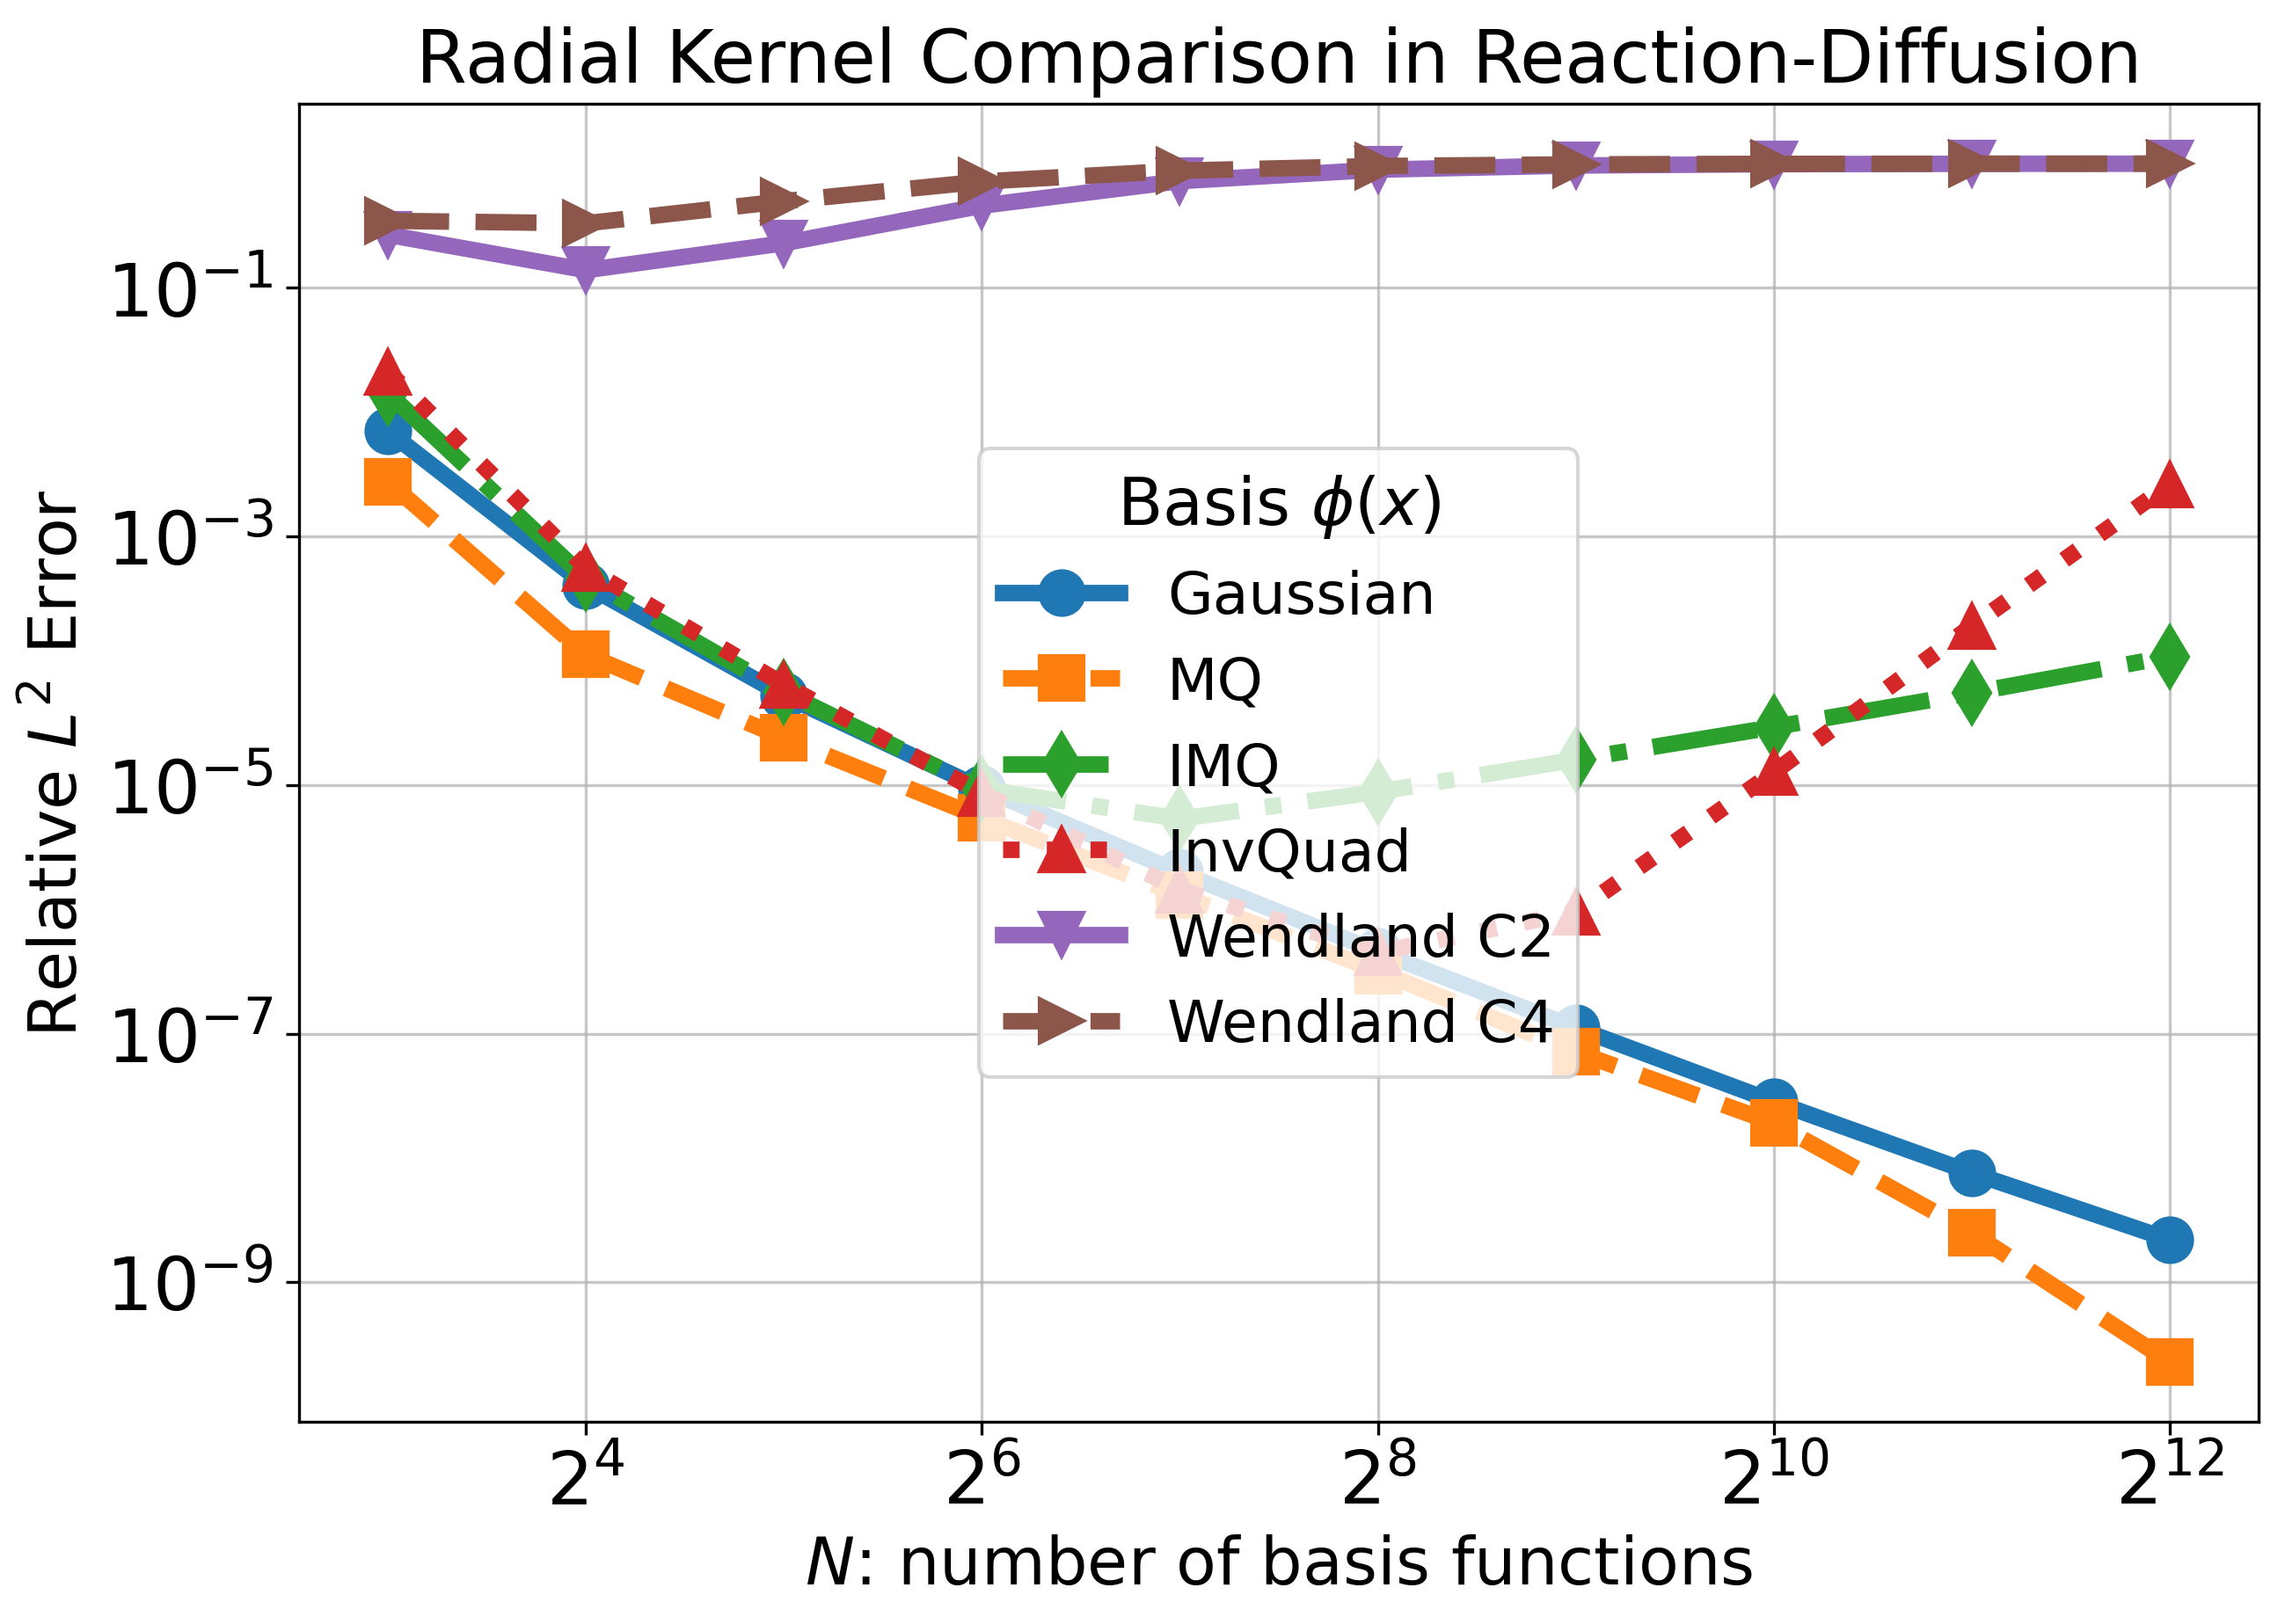

In [4]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt

# Ensure N_values are sorted and unique
N_vals = np.array(sorted(set(N_values)), dtype=float)

# Collect per-kernel error arrays aligned to N_vals
# (in case you built errors out of order)
def align_errors(err_dict, N_vals):
    out = {}
    for name, errs in err_dict.items():
        if len(errs) != len(N_vals):
            # best-effort: truncate or pad with nan
            arr = np.full_like(N_vals, np.nan, dtype=float)
            m = min(len(errs), len(N_vals))
            arr[:m] = np.asarray(errs[:m], dtype=float)
        else:
            arr = np.asarray(errs, dtype=float)
        out[name] = arr
    return out

errors_aligned = align_errors(errors_rbf, N_vals)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 4.5,
    "lines.markersize": 12,
    "grid.alpha": 0.7,
     "figure.dpi": 300
})


fig, ax = plt.subplots(figsize=(9, 6.5), dpi=300)

markers = cycle(['o', 's', 'd', '^', 'v', '>', '<', 'p', 'h'])
linestyles = ['-', '--', '-.', ':']

for i, (name, errs) in enumerate(errors_aligned.items()):
    # mask NaNs (if any)
    mask = ~np.isnan(errs)
    if not np.any(mask):
        continue
    ax.plot(
        N_vals[mask],
        errs[mask],
        linestyle=linestyles[i % len(linestyles)],
        marker=next(markers),
        linewidth=4.5,
        label=name,
    )

ax.set_xscale('log', base = 2)
ax.set_yscale('log')
ax.set_title('Radial Kernel Comparison in Reaction-Diffusion')
ax.set_xlabel(r'$N$: number of basis functions')
ax.set_ylabel(r'Relative $L^2$ Error')
ax.tick_params(labelsize=20)
ax.grid(True, which='both', linestyle='-', alpha=0.7)
ax.legend(title=r'Basis $\phi(x)$', fontsize=16, title_fontsize=18, loc='center')

plt.tight_layout()
plt.savefig('./Outputs/1D_ReactionDiffusion/fig4_reactiondiffusion.png', dpi = 300)


# Benchmark Sweeping $\beta$ - penalty parameter for boundary conditions. 

# T = 1.5

In [5]:
# ---- helper for c(T, tau)
def c_from_T(T, tau):
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# ---- settings
tau = 1e-15
T = 1.5
c_shape = float(c_from_T(T, tau))   # your code uses eps = c_shape * N
N_list = [256, 512, 1024, 2048]
beta_values = np.logspace(1, 10, num=10)  # 1e1 ... 1e10 (10 points)

# ---- storage: dict of {N: [errors vs beta]}
errors_vs_beta = {N: [] for N in N_list}

# ---- run sweep
for beta in beta_values:
    for N in N_list:
        rel_L2_sq, peak_mb, runtime_s = run_rbf_solver(
            N=N,
            rbf_type="Gaussian",
            L=5.0,
            Amplitude=50.0,
            beta=float(beta),
            tau=tau,
            c_shape=c_shape,   # => eps = c_shape * N
            zeta=2,
            T_cent=1.0,
            use_trapezoid_weights=True,
            penalty_prefactor=1.0,
            use_sqrtN_rep=True,
            jitter=False
        )
        errors_vs_beta[N].append(rel_L2_sq)

# ---- pretty print a table
header = ["beta"] + [f"N={N}" for N in N_list]
print("{:>12s}  ".format(header[0]) + "  ".join(f"{h:>12s}" for h in header[1:]))
for i, beta in enumerate(beta_values):
    row = [f"{beta:12.3e}"] + [f"{errors_vs_beta[N][i]:12.3e}" for N in N_list]
    print("  ".join(row))

        beta         N=256         N=512        N=1024        N=2048
   1.000e+01     2.744e-02     2.105e-02     1.352e-02     6.927e-03
   1.000e+02     4.310e-04     4.151e-04     3.870e-04     3.397e-04
   1.000e+03     4.873e-06     4.660e-06     4.549e-06     4.463e-06
   1.000e+04     2.015e-07     7.815e-08     5.696e-08     5.376e-08
   1.000e+05     1.357e-07     1.950e-08     3.944e-09     2.659e-09
   1.000e+06     1.332e-07     1.766e-08     2.671e-09     1.569e-09
   1.000e+07     1.330e-07     1.752e-08     2.584e-09     1.500e-09
   1.000e+08     1.329e-07     1.751e-08     2.576e-09     1.494e-09
   1.000e+09     1.329e-07     1.750e-08     2.575e-09     1.493e-09
   1.000e+10     1.329e-07     1.751e-08     2.567e-09     1.493e-09


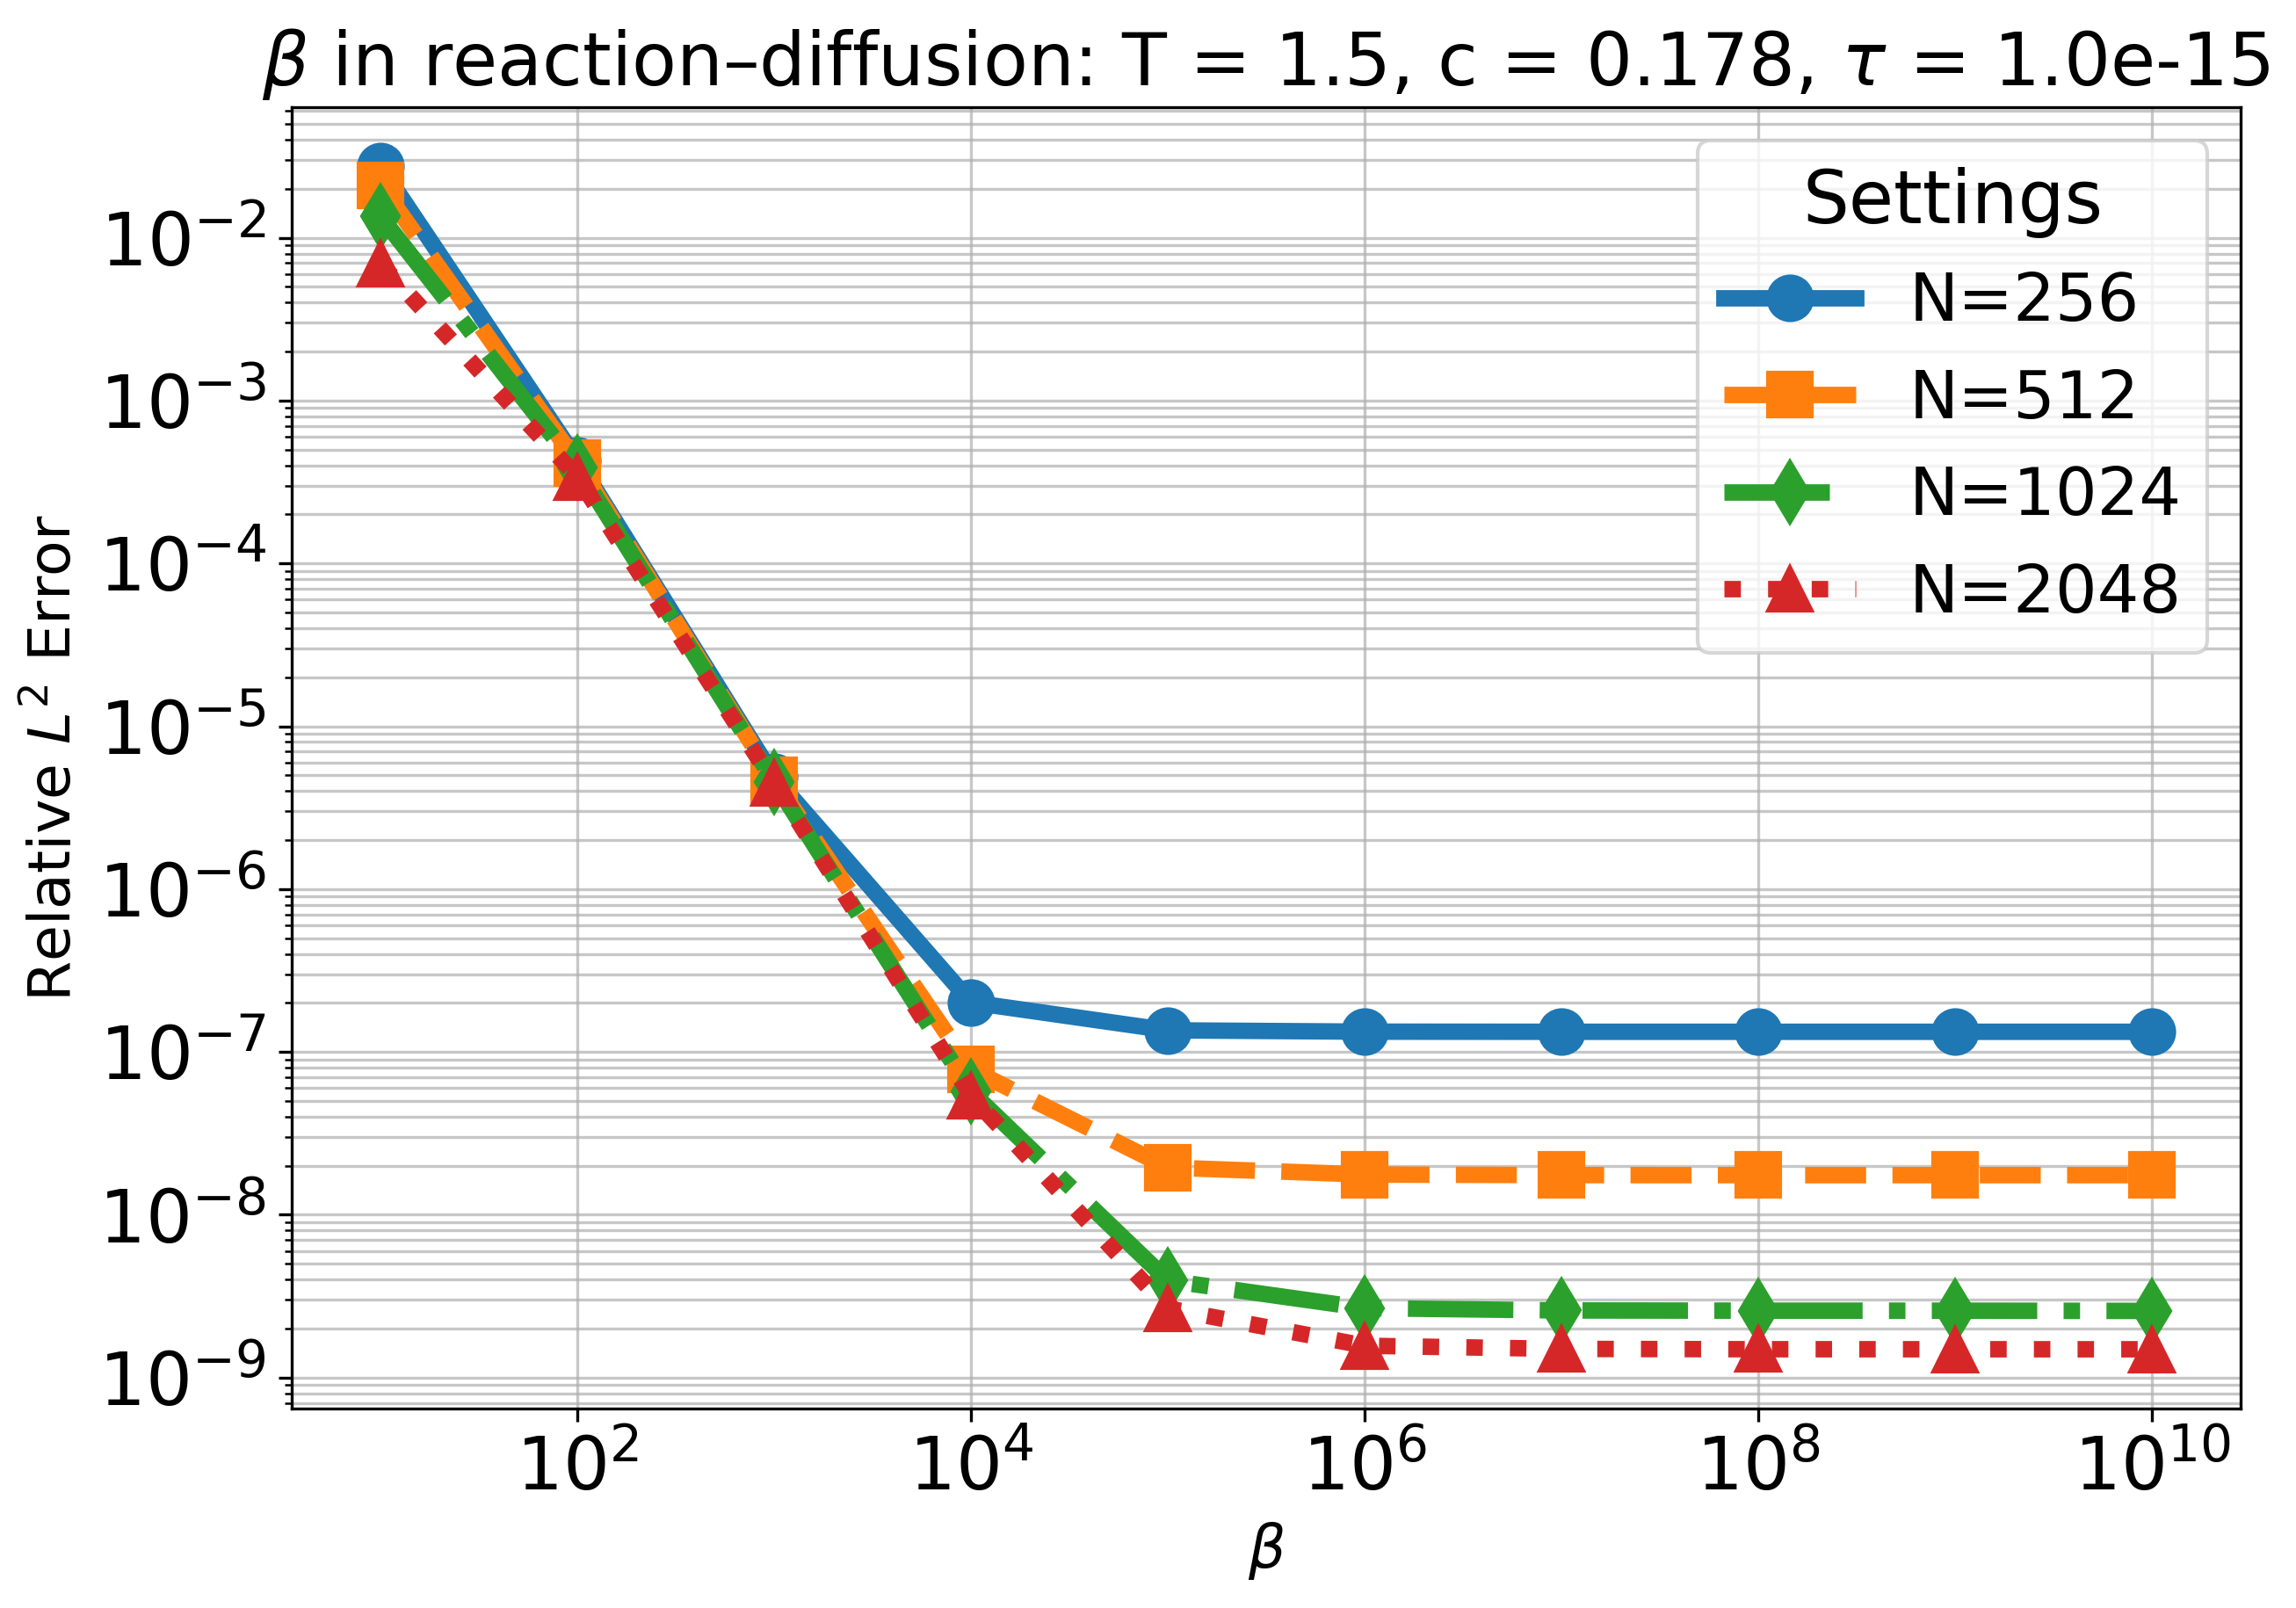

In [6]:
from itertools import cycle

# Assumes you already have:
# beta_values (1D array)
# errors_vs_beta = {N: [errs...]}  # same length as beta_values for each N
# If N_list not defined, infer it:
try:
    N_list
except NameError:
    N_list = sorted(errors_vs_beta.keys())



plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "legend.fontsize": 18,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 12,
    "grid.alpha": 0.7,
})

# Ensure cycles
marker_cyc = cycle(['o', 's', 'd', '^', 'v', '>', '<', 'p', 'h'])
linestyle_cyc = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(9, 6.5), dpi=300)

for N in N_list:
    mk = next(marker_cyc)
    ls = next(linestyle_cyc)
    ax.loglog(beta_values, errors_vs_beta[N], linestyle=ls, marker=mk, label=f"N={N}")

ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(rf"$\beta$ in reaction–diffusion: T = {T}, c = {c_shape:.3f}, $\tau$ = {tau:.1e}")
ax.grid(True, which='both', linestyle='-', alpha=0.7)
ax.legend(title="Settings")
plt.tight_layout()
plt.savefig('./Outputs/1D_ReactionDiffusion/fig13_reactiondiffusion.png', dpi = 300)


# T = 2.0

In [5]:
# ---- helper for c(T, tau)
def c_from_T(T, tau):
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))

# ---- settings
tau = 1e-15
T = 2.0
c_shape = float(c_from_T(T, tau))   # your code uses eps = c_shape * N
N_list = [256, 512, 1024, 2048]
beta_values = np.logspace(1, 10, num=10)  # 1e2 ... 1e10 (12 points)

# ---- storage: dict of {N: [errors vs beta]}
errors_vs_beta = {N: [] for N in N_list}

# ---- run sweep
for beta in beta_values:
    for N in N_list:
        rel_L2_sq, peak_mb, runtime_s = run_rbf_solver(
            N=N,
            rbf_type="Gaussian",
            L=5.0,
            Amplitude=50.0,
            beta=float(beta),
            tau=tau,
            c_shape=c_shape,   # => eps = c_shape * N
            zeta=2,
            T_cent=1.0,
            use_trapezoid_weights=True,
            penalty_prefactor=1.0,
            use_sqrtN_rep=True,
            jitter=False
        )
        errors_vs_beta[N].append(rel_L2_sq)

# ---- pretty print a table
header = ["beta"] + [f"N={N}" for N in N_list]
print("{:>12s}  ".format(header[0]) + "  ".join(f"{h:>12s}" for h in header[1:]))
for i, beta in enumerate(beta_values):
    row = [f"{beta:12.3e}"] + [f"{errors_vs_beta[N][i]:12.3e}" for N in N_list]
    print("  ".join(row))

        beta         N=256         N=512        N=1024        N=2048
   1.000e+01     3.218e-02     2.966e-02     2.554e-02     1.955e-02
   1.000e+02     4.329e-04     4.168e-04     4.033e-04     3.863e-04
   1.000e+03     7.156e-06     5.576e-06     4.850e-06     4.491e-06
   1.000e+04     7.461e-07     2.790e-07     1.335e-07     8.121e-08
   1.000e+05     4.775e-07     1.214e-07     3.336e-08     1.023e-08
   1.000e+06     4.543e-07     1.094e-07     2.708e-08     6.864e-09
   1.000e+07     4.521e-07     1.082e-07     2.649e-08     6.565e-09
   1.000e+08     4.518e-07     1.081e-07     2.643e-08     6.536e-09
   1.000e+09     4.518e-07     1.081e-07     2.642e-08     6.533e-09
   1.000e+10     4.518e-07     1.081e-07     2.640e-08     6.533e-09


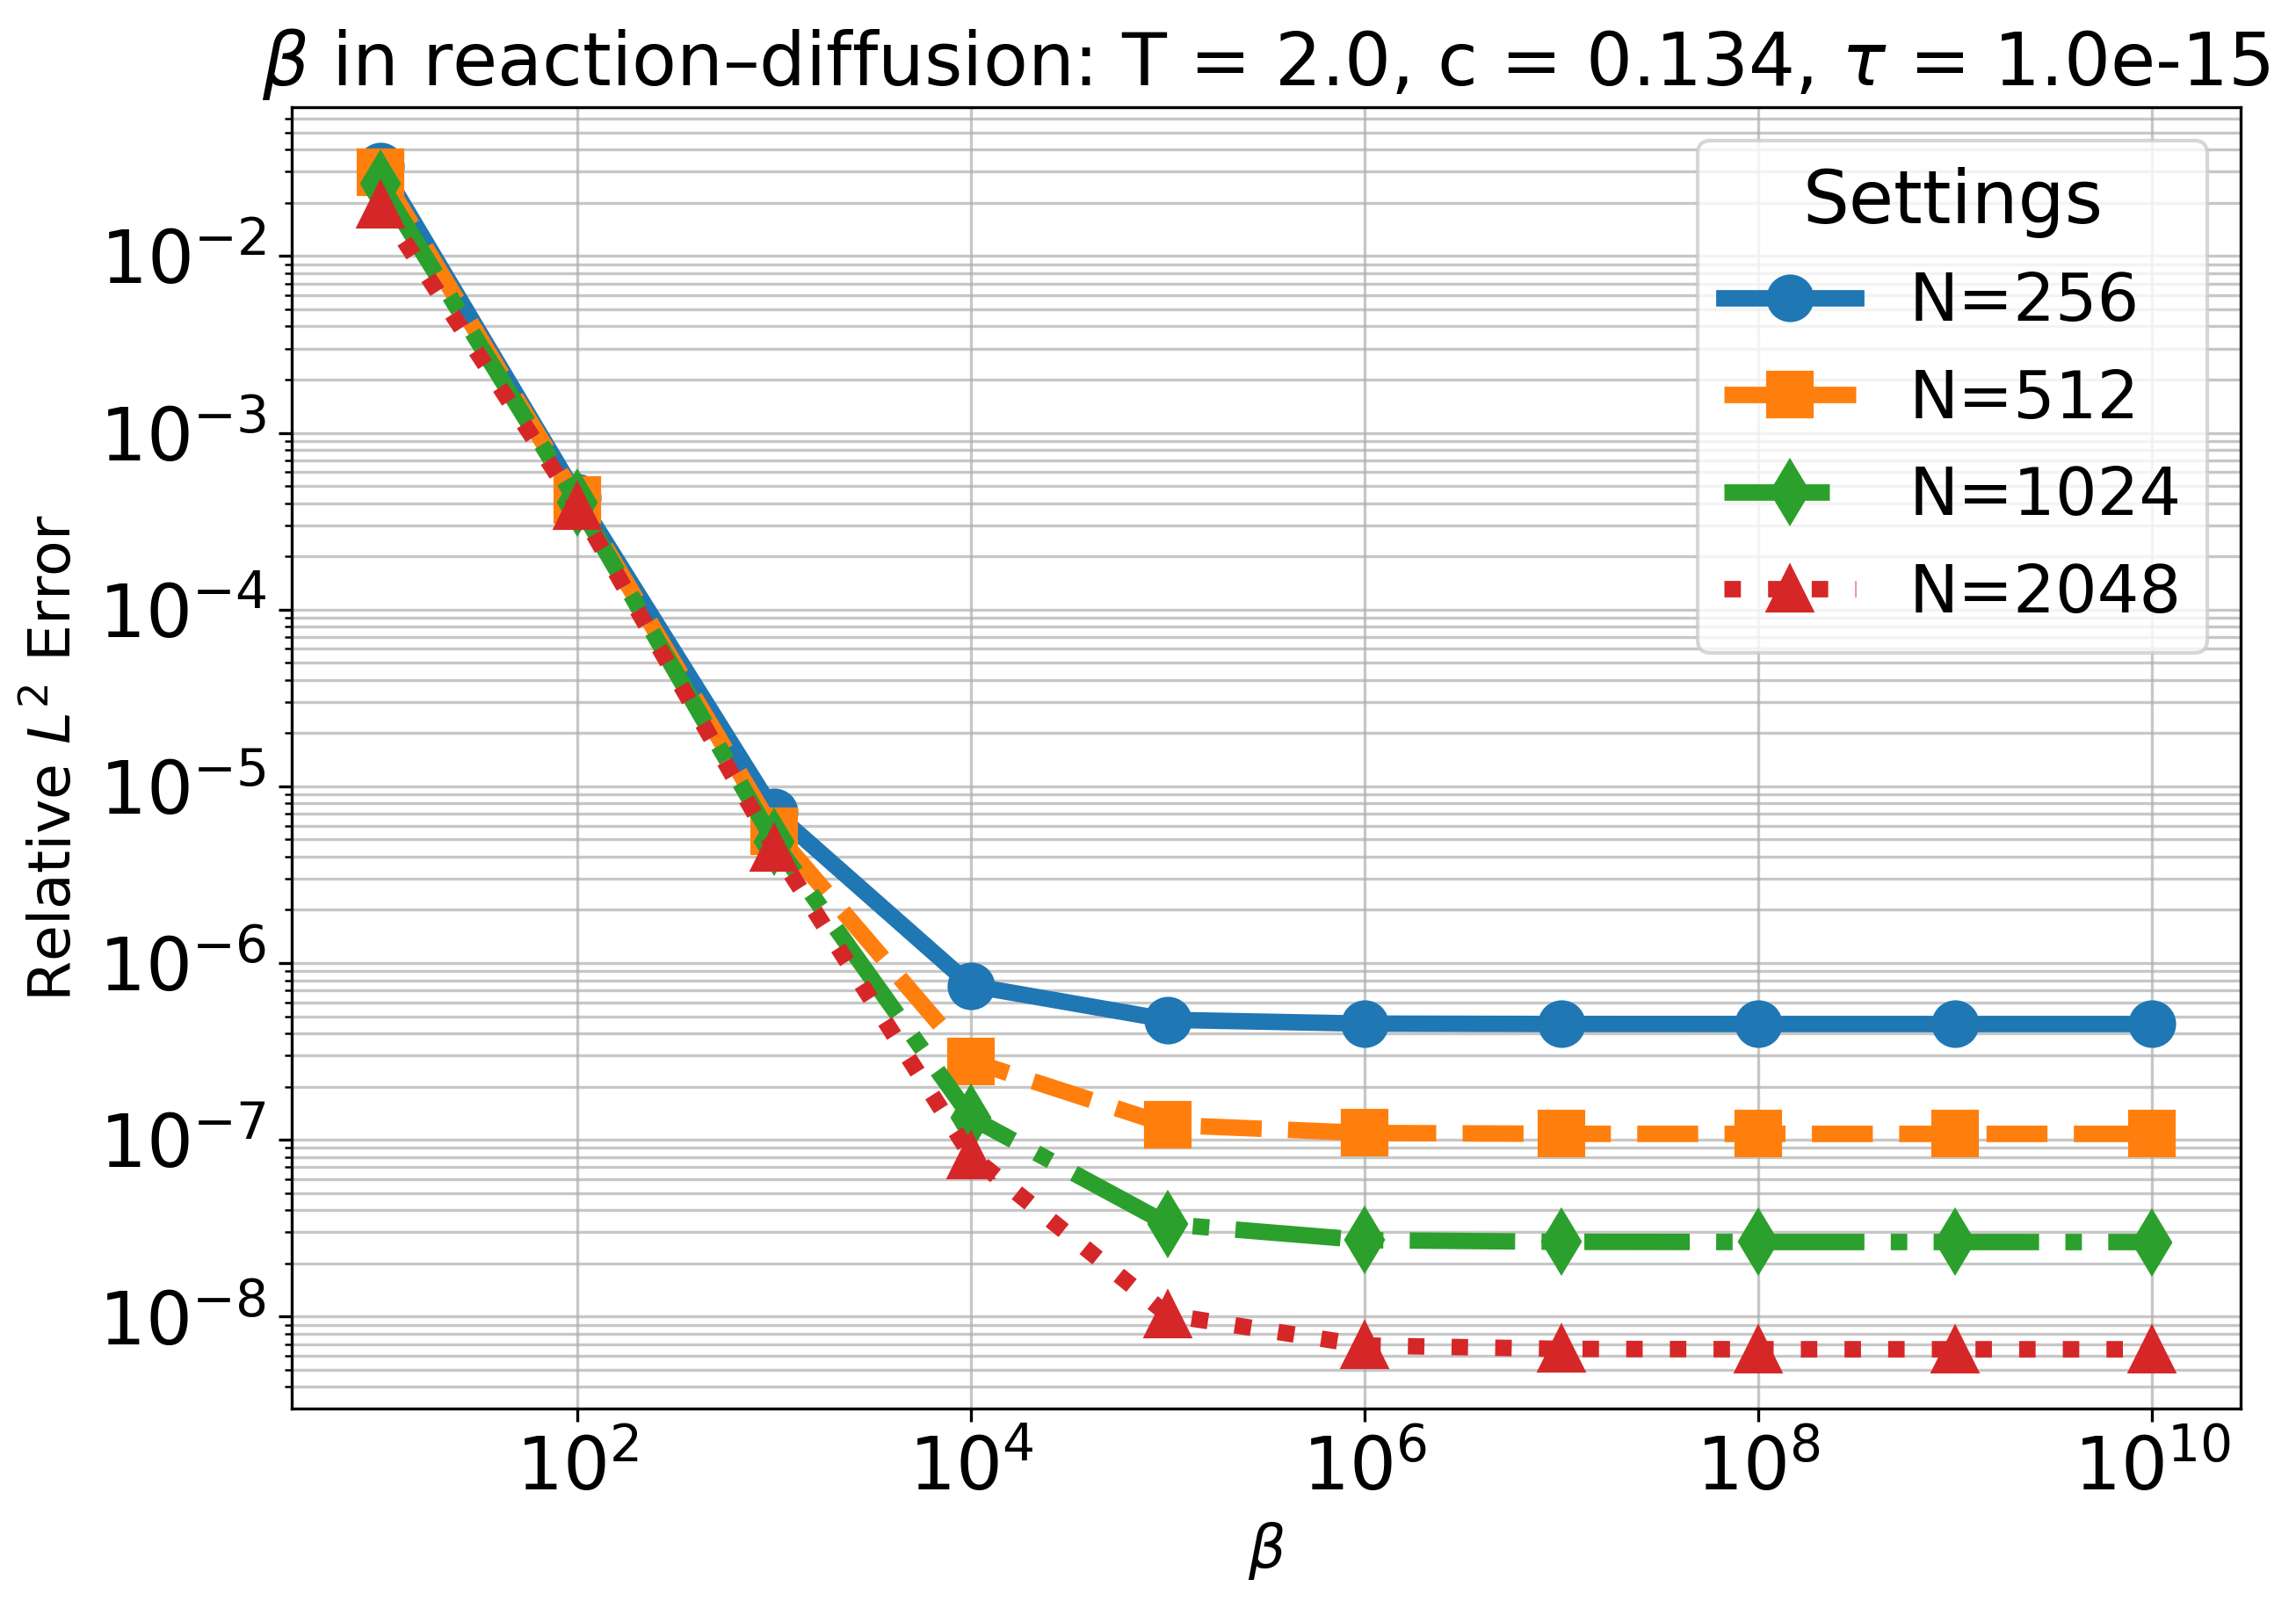

In [6]:
from itertools import cycle

# Assumes you already have:
# beta_values (1D array)
# errors_vs_beta = {N: [errs...]}  # same length as beta_values for each N
# If N_list not defined, infer it:
try:
    N_list
except NameError:
    N_list = sorted(errors_vs_beta.keys())



plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "legend.fontsize": 18,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "lines.linewidth": 4.5,
    "lines.markersize": 12,
    "grid.alpha": 0.7,
})


# Ensure cycles
marker_cyc = cycle(['o', 's', 'd', '^', 'v', '>', '<', 'p', 'h'])
linestyle_cyc = cycle(['-', '--', '-.', ':'])

fig, ax = plt.subplots(figsize=(9, 6.5), dpi=300)

for N in N_list:
    mk = next(marker_cyc)
    ls = next(linestyle_cyc)
    ax.loglog(beta_values, errors_vs_beta[N], linestyle=ls, marker=mk, label=f"N={N}")

ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"Relative $L^2$ Error")
ax.set_title(rf"$\beta$ in reaction–diffusion: T = {T}, c = {c_shape:.3f}, $\tau$ = {tau:.1e}")
ax.grid(True, which='both', linestyle='-', alpha=0.7)
ax.legend(title="Settings")
plt.tight_layout()
plt.savefig('./Outputs/1D_ReactionDiffusion/fig14_reactiondiffusion.png', dpi = 300)
